# Pixelation – Batch Version
Reads all images from `test_cases/`, applies pixelation (block averaging), saves to `outputs/`.

Original function `pixelate_image` and `derive_block_color` are kept **exactly** as provided.

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [17]:
# ===== CONFIGURATION =====
INPUT_DIR = Path(r"D:\pythonProject\Private\CUHKSZ Schoolwork\Y1T2S\ECE4512\Pixelate Everything\test_cases")    # <-- change as needed
OUTPUT_DIR = Path(r"D:\pythonProject\Private\CUHKSZ Schoolwork\Y1T2S\ECE4512\Pixelate Everything\derive_grid_logic\ver.1\outputs")   # <-- change as needed
BLOCK_SIZE = 10          # pixelation block size
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
# =========================

# Ensure output directory exists
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Check input directory
if not INPUT_DIR.exists():
    raise FileNotFoundError(f"Input folder not found: {INPUT_DIR.resolve()}")

In [18]:
# ===== ORIGINAL FUNCTIONS (KEPT UNCHANGED) =====
# The following code is exactly as provided in derive_grid.py

# path = r""
# outpath = r""

# BLOCK_SIZE = 10
# EDGE_THRESH = 0.3
# EDGE_COLOR = [0, 0, 0] # default black


def derive_block_color(block):
    avg = np.average(block, axis=(0, 1))
    return np.clip(avg, 0, 255).astype(np.uint8)


def pixelate_image(img, block_size=5):
    h, w = img.shape[:2]
    new_w = w // block_size
    new_h = h // block_size
    resized_w = new_w * block_size
    resized_h = new_h * block_size

    resized = cv2.resize(img, (resized_w, resized_h), interpolation = cv2.INTER_NEAREST)
    
    pixelated = np.zeros((new_h, new_w, 3), dtype=np.uint8)

    for row in range(new_h):
        for col in range(new_w):
            block = resized[row * block_size:(row + 1) * block_size, col * block_size:(col + 1) * block_size]
            pixelated[row][col] = derive_block_color(block)

    return pixelated

In [19]:
# ===== BATCH PROCESSING =====
processed = 0
for img_path in sorted(INPUT_DIR.iterdir()):
    # Skip non-image files
    if img_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue
    if not img_path.is_file():
        continue

    # Build output path
    out_name = f"{img_path.stem}_pixelated_block{BLOCK_SIZE}.png"
    out_path = OUTPUT_DIR / out_name

    # Skip duplicates
    if out_path.exists():
        print(f"⏩ Skipping (already exists): {img_path.name}")
        continue

    # Read image
    img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img is None:
        print(f"⚠️  Could not read: {img_path.name}")
        continue

    print(f"Processing: {img_path.name} ...")
    pixelated = pixelate_image(img, block_size=BLOCK_SIZE)
    cv2.imwrite(str(out_path), pixelated)

    processed += 1

print(f"\nDone. {processed} image(s) processed. Output folder: {OUTPUT_DIR.resolve()}")

⏩ Skipping (already exists): albert.jpg
⏩ Skipping (already exists): gradient_descending.png
⏩ Skipping (already exists): hatsune_miku.jpg
⏩ Skipping (already exists): mona_lisa.jpg
⏩ Skipping (already exists): test_case.png
⏩ Skipping (already exists): van_gogh_starsky.jpg
⏩ Skipping (already exists): why_are_you_sitting.jpg

Done. 0 image(s) processed. Output folder: D:\pythonProject\Private\CUHKSZ Schoolwork\Y1T2S\ECE4512\Pixelate Everything\derive_grid_logic\ver.1\outputs


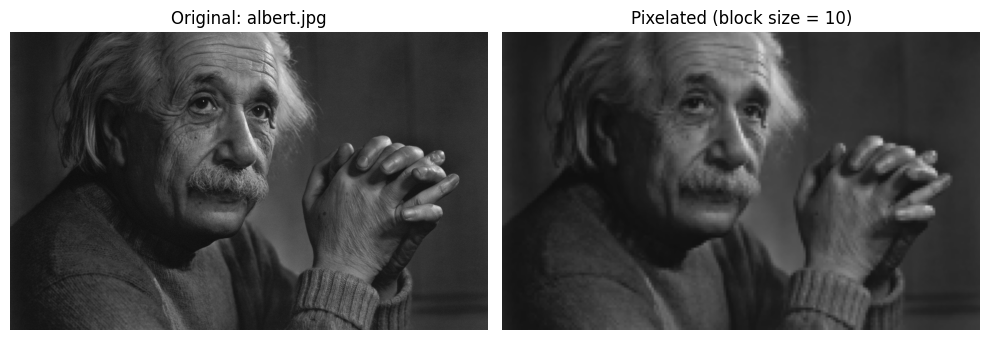

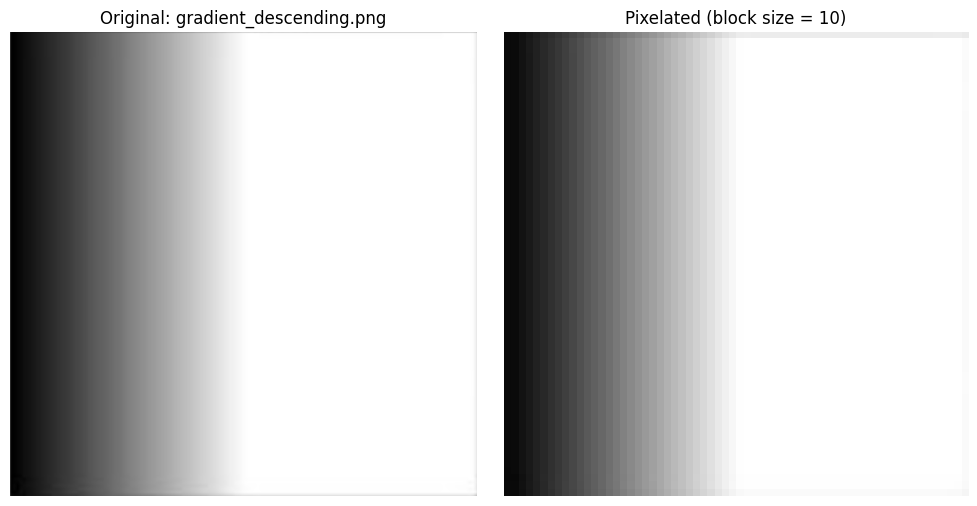

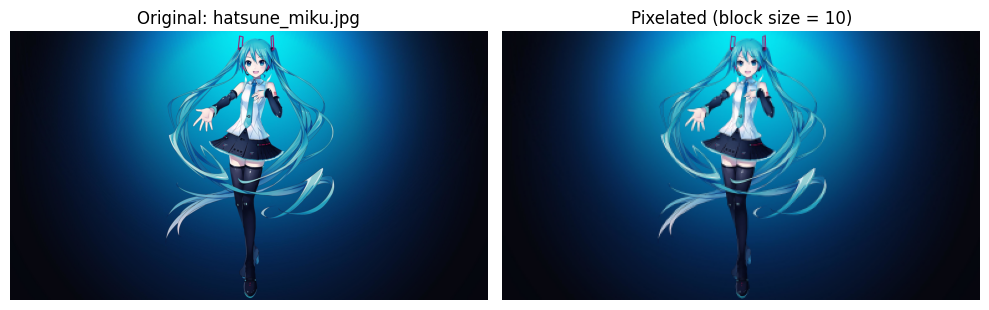

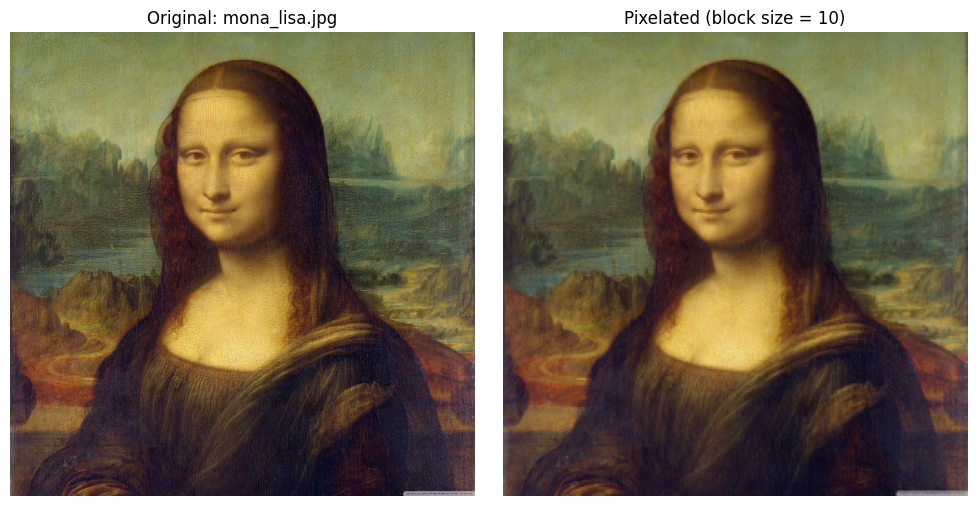

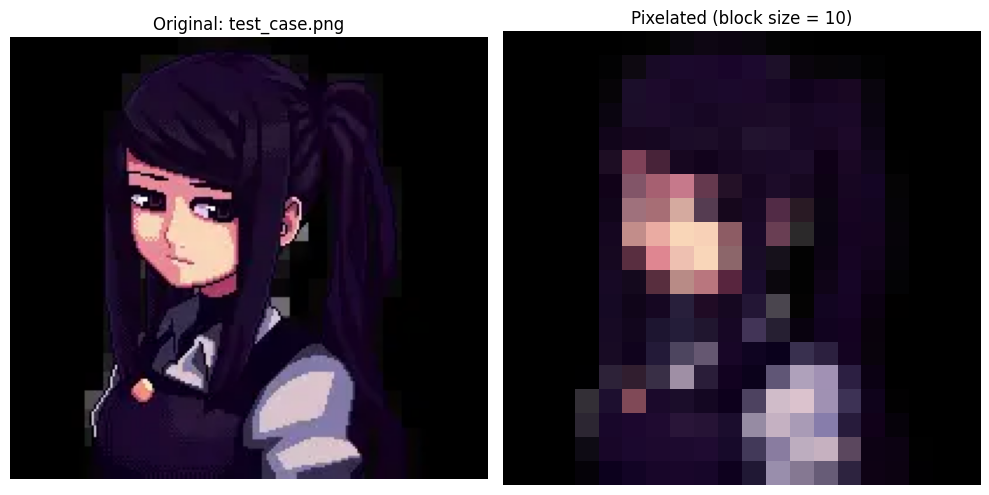

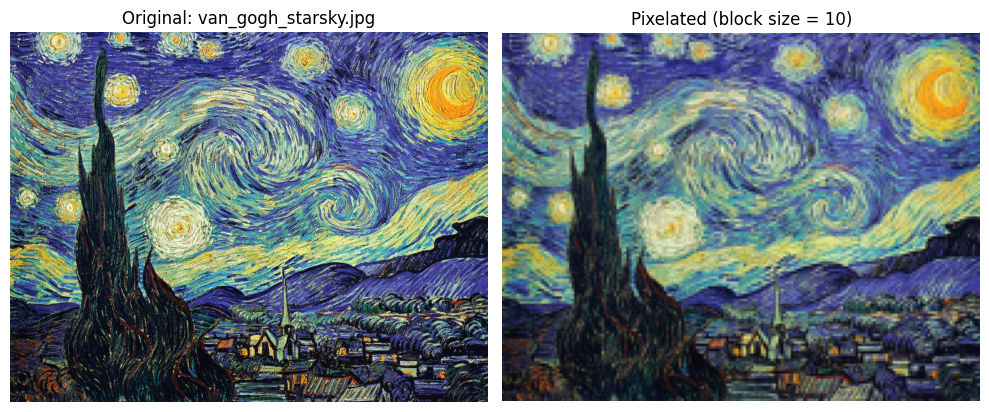

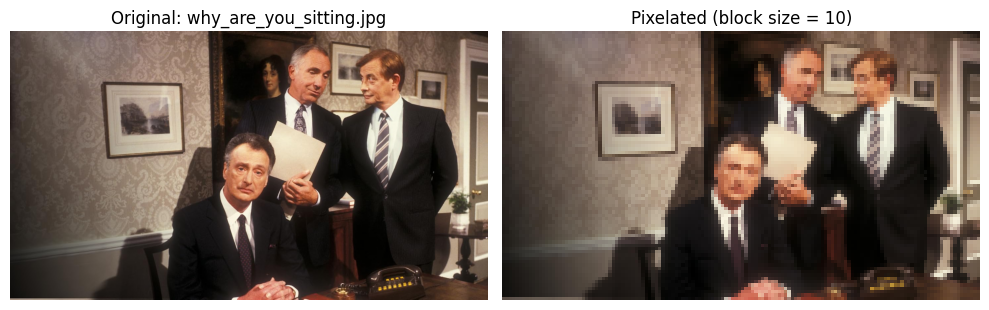

In [20]:
# Toggle on/off
SHOW_COMPARISONS = True

if SHOW_COMPARISONS:
    for img_path in sorted(INPUT_DIR.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        out_name = f"{img_path.stem}_pixelated_block{BLOCK_SIZE}.png"
        out_path = OUTPUT_DIR / out_name
        if not out_path.exists():
            continue

        orig_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        pixelated_bgr = cv2.imread(str(out_path), cv2.IMREAD_COLOR)
        if orig_bgr is None or pixelated_bgr is None:
            continue

        # BGR -> RGB for matplotlib
        orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
        pixelated_rgb = cv2.cvtColor(pixelated_bgr, cv2.COLOR_BGR2RGB)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
        ax1.imshow(orig_rgb)
        ax1.set_title(f"Original: {img_path.name}")
        ax1.axis("off")
        ax2.imshow(pixelated_rgb)
        ax2.set_title(f"Pixelated (block size = {BLOCK_SIZE})")
        ax2.axis("off")
        plt.tight_layout()
        plt.show()